# Notebook 4 — Feature extraction

*SWC ENC 2026 · ephys-pop module*

We have a pile of unlabelled snippets. To tell the neurons apart we describe each
spike by a few **features** — numbers that differ between units but stay similar
within a unit. Three natural ones:

- **where** the spike is — its **depth** on the probe,
- **how big** it is — its **amplitude**,
- **what shape** it has — captured by **PCA** of the waveform.

**In this notebook you will:**
1. **Localize** each spike: peak channel, amplitude, depth.
2. See units separate in the depth–amplitude plane.
3. Use **PCA** to capture waveform shape — and see when you need it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import picosort as ps

rec = ps.make_recording(n_units=6, duration_s=20.0, seed=0)
whitened, filtered, W = ps.preprocess(rec)
times, peak_channels = ps.detect_spikes(whitened, rec.probe, rec.fs, threshold=5.0)
snippets, times = ps.extract_snippets(filtered, times, peak_channels=peak_channels)
print("snippets:", snippets.shape)

snippets: (421, 32, 61)


## 1. Localize: depth and amplitude

A spike's **peak-to-peak amplitude** on each channel is its footprint. The channel
where it's biggest is the **peak channel**, and its size there is the spike's
**amplitude**. Its **depth** is the footprint-weighted average channel position —
the centre of mass — using only channels near the peak, so probe-wide noise doesn't
drag the estimate.

**Exercise 1** *(~7 min)*. Complete `localize`: from the `(n_spikes, n_channels, n_samples)`
snippets, compute peak-to-peak per channel, then peak channel, amplitude, and the
centre-of-mass depth over channels within `radius_um` of the peak.

> **Check / unstuck.** Amplitudes should span ~120–320 µV; depths should cover the
> probe (roughly 80–560 µm). Stuck? Use `ps.localize(snippets, rec.probe)`.

In [2]:
def localize(snippets, probe, radius_um=60.0):
    p2p = snippets.max(axis=2) - snippets.min(axis=2)      # (n_spikes, n_channels)
    peak_channel = np.argmax(p2p, axis=1)
    amplitude = p2p[np.arange(len(p2p)), peak_channel]
    dy = np.abs(probe.y[None, :] - probe.y[peak_channel][:, None])
    w = p2p * (dy <= radius_um)
    depth = (w * probe.y[None, :]).sum(axis=1) / w.sum(axis=1)
    return peak_channel, amplitude, depth

peak_channel, amplitude, depth = localize(snippets, rec.probe)
print(f"amplitude range: {amplitude.min():.0f}–{amplitude.max():.0f} µV")
print(f"depth range: {depth.min():.0f}–{depth.max():.0f} µm")

amplitude range: 73–292 µV
depth range: 38–564 µm


## 2. The feature space

Plot every spike as a point in the **depth–amplitude plane**. Even though we have no
labels, the units jump out as separated clouds: each neuron sits at its own depth
and fires at its own amplitude. This is what makes the sorting possible.

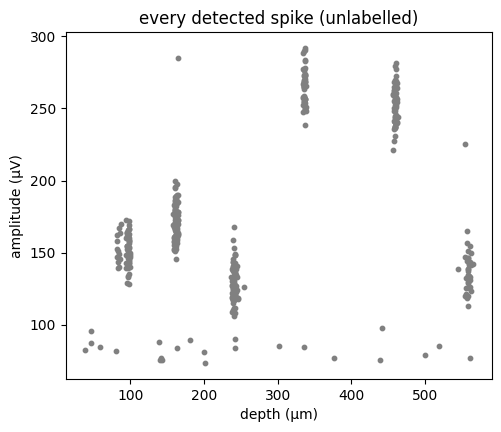

In [3]:
ps.plotting.plot_feature_space(depth, amplitude, title="every detected spike (unlabelled)")
plt.show()

Those clouds are the units, waiting to be found — that's Notebook 5. But first, two
more features to make the clouds even cleaner, and to handle a case depth and
amplitude *can't*.

## 3. Shape, via PCA

Two neurons can sit at the same depth and fire at the same amplitude yet have
different **waveform shapes** — a narrow spike vs a broad one. Depth and amplitude
can't tell them apart, but shape can. The trouble is a waveform is 61 numbers; we
want a couple. **Principal component analysis** finds the few directions along which
waveforms actually vary and re-expresses each waveform by its **scores** on them.

Since the spikes of one neuron are near-copies, a couple of components capture almost
all the variation. Look at the **scree plot** — the fraction of variance each
component explains:

<details>
<summary><b>▸ The math: what PCA actually computes (optional)</b></summary>

Stack the (centred) waveforms as rows of a matrix $X$ of size $n \times p$
($n$ spikes, $p = 61$ samples). We want the single direction $v$ (a unit vector in
waveform space) along which the projected waveforms $Xv$ vary the most:

$$\max_{\lVert v\rVert = 1}\ \mathrm{Var}(Xv) = \max_{\lVert v\rVert=1}\ v^\top C\, v,
\qquad C = \tfrac{1}{n} X^\top X$$

where $C$ is the $p\times p$ covariance of the waveforms. The Lagrangian
$v^\top C v - \lambda(v^\top v - 1)$ has stationary points where

$$C\,v = \lambda\, v,$$

so the principal directions are the **eigenvectors of the covariance**, and each
one's variance is its **eigenvalue** $\lambda$. The second PC is the next eigenvector,
and so on — orthogonal directions of decreasing variance.

In practice we skip forming $C$ and take the **singular value decomposition**
$X = U S V^\top$ directly: the columns of $V$ are the principal directions (the
`components`), the **scores** are $XV = US$, and the variance explained by component
$k$ is $s_k^2 / \sum_j s_j^2$ — the scree plot. Why a *few* components suffice is the
**Eckart–Young theorem**: keeping the top $k$ gives the best possible rank-$k$
approximation of $X$ (smallest reconstruction error). Because every spike of a neuron
is nearly the same waveform, $X$ is close to low-rank, so 2–3 components rebuild it
almost perfectly and the rest is noise.
</details>

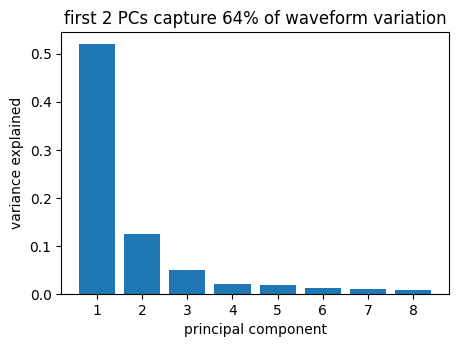

In [4]:
waveforms = ps.peak_waveforms(snippets)          # (n_spikes, n_samples)
ev = ps.explained_variance(waveforms, n_components=8)
plt.figure(figsize=(5, 3.4))
plt.bar(np.arange(1, 9), ev)
plt.xlabel("principal component"); plt.ylabel("variance explained")
plt.title(f"first 2 PCs capture {ev[:2].sum():.0%} of waveform variation"); plt.show()

**Exercise 2** *(~6 min)*. Complete `pca_scores`: centre the waveforms, take the SVD, and
project onto the top `k` right-singular vectors (the principal components). Return
the scores.

> **Check / unstuck.** `scores` should be `(n_spikes, k)`. The PC1–PC2 scatter below
> should show structure (blobs). Stuck? Use `ps.pca_features(waveforms, 2)[0]`.

scores: (421, 2)


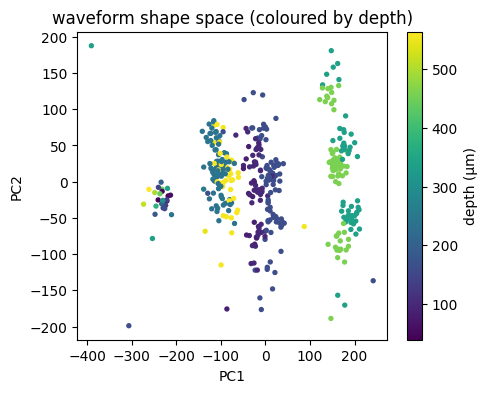

In [5]:
def pca_scores(waveforms, k=2):
    X = waveforms - waveforms.mean(axis=0)
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    return X @ Vt[:k].T

scores = pca_scores(waveforms, 2)
print("scores:", scores.shape)
plt.figure(figsize=(5, 4))
plt.scatter(scores[:, 0], scores[:, 1], s=8, c=depth, cmap="viridis")
plt.colorbar(label="depth (µm)"); plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("waveform shape space (coloured by depth)"); plt.show()

## 4. When shape is the only clue *(optional)*

*Skippable.* To see why shape matters, build two units at the **same depth** and
**same amplitude** but with different waveform widths. In the depth–amplitude plane
they're one blob; in the PC (shape) plane they split cleanly. On our main recording
depth and amplitude are enough, but in dense tissue shape is what saves you.

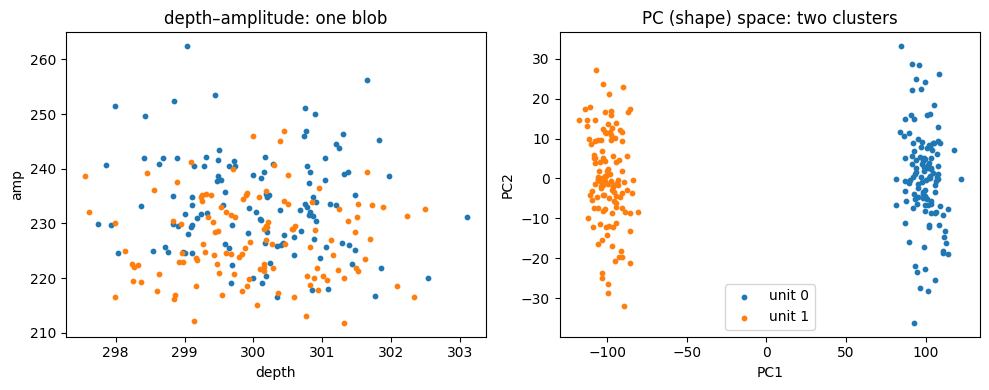

In [6]:
probe = rec.probe
def one_unit(width, seed):
    wf = ps.spike_waveform(trough_width=width)
    tmpl = ps.make_template(probe, [0, 300], amplitude=150, waveform=wf)
    # jitter each spike with noise to make a cloud
    rng = np.random.default_rng(seed)
    return np.array([tmpl + rng.normal(0, 8, tmpl.shape) for _ in range(120)])

snips = np.concatenate([one_unit(2.2, 1), one_unit(3.8, 2)])
lab = np.r_[np.zeros(120), np.ones(120)].astype(int)
_, amp2, dep2 = ps.localize(snips, probe)
sc2 = ps.pca_features(ps.peak_waveforms(snips), 2)[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for u in [0, 1]:
    m = lab == u
    axes[0].scatter(dep2[m], amp2[m], s=10, color=ps.plotting.unit_color(u))
    axes[1].scatter(sc2[m, 0], sc2[m, 1], s=10, color=ps.plotting.unit_color(u), label=f"unit {u}")
axes[0].set_title("depth–amplitude: one blob"); axes[0].set_xlabel("depth"); axes[0].set_ylabel("amp")
axes[1].set_title("PC (shape) space: two clusters"); axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].legend(); plt.tight_layout(); plt.show()

## Wrap-up

Each spike is now a handful of numbers: depth, amplitude, and a couple of shape PCs.
In the depth–amplitude plane the units already stand out as separate clouds, and PCA
is there for the harder cases where they don't.

**Next (Notebook 5 — clustering):** turn those clouds into labelled units, and
average each cluster into a template.